# Psychometric Analysis

Equivalent to `BlackRockFileAnalyzer.m` + `VisPsychometricFunction.m` in MATLAB.  
Loads the exported `_trials.csv`, filters to valid trials, fits a logistic function,
and plots the psychometric curve with PSE and Threshold annotations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## 1. Set path to exported CSV

In [2]:
# ── Edit this path ────────────────────────────────────────────────────────
CSV_PATH = (
    "/Users/xuefeiyu/Documents/XuefeiFile/WorkRelated/Data"
    "/Monkey Porthos/in_lab/export_data/2026-03-24"
    "/Blackrock_2026-03-24_trials.csv"
)
ANALYZE_TASK = "time_delay_experiment"
# ─────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} trials from {CSV_PATH.split('/')[-1]}")

Loaded 68 trials from Blackrock_2026-03-24_trials.csv


## 2. Filter trials

Keep only: complete, correct task, valid choice (mirrors `BlackRockFileAnalyzer.m`).

In [3]:
complete = df['Save_complete'] == 1
correct_task = df['Task'] == ANALYZE_TASK
valid_choice = df['Choose_target'].notna()

selected = df[complete & correct_task & valid_choice].copy()

print(f"Complete           : {complete.sum()}")
print(f"Correct task       : {(complete & correct_task).sum()}")
print(f"Valid choice       : {(complete & correct_task & valid_choice).sum()}  ← using these")

Complete           : 68
Correct task       : 68
Valid choice       : 64  ← using these


## 3. Build psychometric matrix

Columns: `[stimulus_dir, choice_rightward]`  
- `stimulus_dir = Requested_target_2_time_offset × Stimulus_direction` (signed asynchrony in ms)
- `choice_rightward = 1` if `Choose_leftright == 1` (chose rightward target)

In [4]:
stimulus     = selected['Requested_target_2_time_offset'].values
direction    = selected['Stimulus_direction'].values
choice_right = (selected['Choose_leftright'] == 1).astype(int).values

# Signed stimulus (positive = target 2 shown later when rightward)
stimulus_dir = stimulus * direction

print(f"Stimulus levels  : {np.unique(stimulus_dir)}")
print(f"N trials         : {len(stimulus_dir)}")

Stimulus levels  : [-200 -100  -50  -25  -12    0   12   25   50  100  200]
N trials         : 64


## 4. Bin proportions per stimulus level

In [5]:
levels = np.unique(stimulus_dir)
prop_right = np.array([
    choice_right[stimulus_dir == lvl].mean() for lvl in levels
])
n_per_level = np.array([
    (stimulus_dir == lvl).sum() for lvl in levels
])

for lvl, p, n in zip(levels, prop_right, n_per_level):
    print(f"  {lvl:+7.0f} ms  → P(right) = {p:.3f}  (n={n})")

     -200 ms  → P(right) = 0.000  (n=8)
     -100 ms  → P(right) = 0.200  (n=5)
      -50 ms  → P(right) = 0.167  (n=6)
      -25 ms  → P(right) = 0.000  (n=6)
      -12 ms  → P(right) = 0.333  (n=6)
       +0 ms  → P(right) = 0.625  (n=8)
      +12 ms  → P(right) = 0.900  (n=10)
      +25 ms  → P(right) = 0.500  (n=2)
      +50 ms  → P(right) = 1.000  (n=6)
     +100 ms  → P(right) = 0.750  (n=4)
     +200 ms  → P(right) = 1.000  (n=3)


## 5. Fit logistic psychometric function

Model: `P(right | x) = 1 / (1 + exp(-(x - PSE) / threshold))`

- **PSE** (Point of Subjective Equality): stimulus value where P(right) = 0.5  
- **Threshold**: steepness of the curve (1/slope)

In [6]:
def logistic(x, pse, threshold):
    """Logistic psychometric function."""
    return 1.0 / (1.0 + np.exp(-(x - pse) / threshold))


p0 = [0.0, 50.0]  # initial guess: PSE=0ms, threshold=50ms

try:
    popt, pcov = curve_fit(
        logistic, stimulus_dir, choice_right,
        p0=p0, maxfev=5000
    )
    pse, threshold = popt
    print(f"PSE       = {pse:.2f} ms")
    print(f"Threshold = {threshold:.2f} ms")
    fit_ok = True
except RuntimeError as e:
    print(f"Fit failed: {e}")
    fit_ok = False

PSE       = -4.63 ms
Threshold = 8.77 ms


## 6. Plot psychometric curve

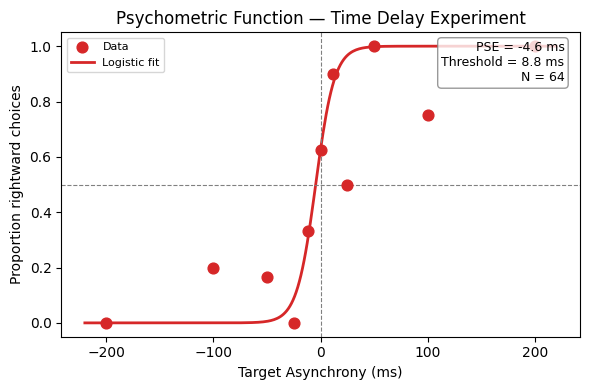

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

# Raw proportions
ax.scatter(
    levels, prop_right,
    color='tab:red', zorder=3, s=60,
    label='Data'
)

# Fitted curve
if fit_ok:
    x_fit = np.linspace(levels.min() - 20, levels.max() + 20, 300)
    y_fit = logistic(x_fit, pse, threshold)
    ax.plot(x_fit, y_fit, color='tab:red', linewidth=2, label='Logistic fit')

# Reference lines
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0.0, color='gray', linestyle='--', linewidth=0.8)

# Annotate PSE / threshold
if fit_ok:
    N = len(stimulus_dir)
    ax.text(
        0.97, 0.97,
        f"PSE = {pse:.1f} ms\nThreshold = {threshold:.1f} ms\nN = {N}",
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', alpha=0.8)
    )

ax.set_xlabel('Target Asynchrony (ms)')
ax.set_ylabel('Proportion rightward choices')
ax.set_ylim(-0.05, 1.05)
ax.set_title('Psychometric Function — Time Delay Experiment')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()